# Importing Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


# Data Import

In [2]:

file_path = "Health_conditions_among_children_under_age_18__by_selected_characteristics__United_States.csv"

df = pd.read_csv(file_path)

# Show the first few rows of the dataset and some basic statistics
df.head(2)


,INDICATOR,PANEL,PANEL_NUM,UNIT,UNIT_NUM,STUB_NAME,STUB_NAME_NUM,STUB_LABEL,STUB_LABEL_NUM,YEAR,YEAR_NUM,AGE,AGE_NUM,ESTIMATE,SE,FLAG
0,Health conditions among children under age 18,Current asthma among persons under 18 years,1,"Percent of children, crude",1,Total,0,Under 18 years,0.0,1997-1999,1,Under 18 years,0.0,NaN,NaN,...
1,Health conditions among children under age 18,Current asthma among persons under 18 years,1,"Percent of children, crude",1,Total,0,Under 18 years,0.0,2000-2002,2,Under 18 years,0.0,NaN,NaN,...


In [16]:
df.describe(include='all')

,INDICATOR,PANEL,PANEL_NUM,UNIT,UNIT_NUM,STUB_NAME,STUB_NAME_NUM,STUB_LABEL,STUB_LABEL_NUM,YEAR,YEAR_NUM,AGE,AGE_NUM,ESTIMATE,SE,FLAG
count,2744,2744,2744.000000,2744,2744.0,2744,2744.000000,2744,2744.000000,2744,2744.000000,2744,2744.000000,2516.000000,2516.000000,287
unique,1,8,NaN,1,NaN,7,NaN,25,NaN,14,NaN,5,NaN,NaN,NaN,2
top,Health conditions among children under age 18,Current asthma among persons under 18 years,NaN,"Percent of children, crude",NaN,Race,NaN,2 or more races,NaN,1997-1999,NaN,Under 18 years,NaN,NaN,NaN,*
freq,2744,350,NaN,2744,NaN,672,NaN,112,NaN,196,NaN,2324,NaN,NaN,NaN,179
mean,NaN,NaN,4.520408,NaN,1.0,NaN,3.500000,NaN,3.718980,NaN,7.500000,NaN,0.268805,8.480008,0.441852,NaN
std,NaN,NaN,2.309363,NaN,0.0,NaN,1.733839,NaN,1.737358,NaN,4.031864,NaN,0.679294,4.287880,0.364903,NaN
min,NaN,NaN,1.000000,NaN,1.0,NaN,0.000000,NaN,0.000000,NaN,1.000000,NaN,0.000000,1.100000,0.100000,NaN
25%,NaN,NaN,2.000000,NaN,1.0,NaN,2.000000,NaN,2.200000,NaN,4.000000,NaN,0.000000,5.200000,0.200000,NaN
50%,NaN,NaN,5.000000,NaN,1.0,NaN,3.000000,NaN,3.600000,NaN,7.500000,NaN,0.000000,7.100000,0.300000,NaN
75%,NaN,NaN,7.000000,NaN,1.0,NaN,5.000000,NaN,5.200000,NaN,11.000000,NaN,0.000000,11.225000,0.500000,NaN


In [3]:
# List all the column names
column_names = df.columns.tolist()

# Check for missing values in each column
missing_values = df.isnull().sum()

# Provide some basic statistics for numeric columns
basic_stats = df.describe()

column_names, missing_values, basic_stats


(['INDICATOR',
  'PANEL',
  'PANEL_NUM',
  'UNIT',
  'UNIT_NUM',
  'STUB_NAME',
  'STUB_NAME_NUM',
  'STUB_LABEL',
  'STUB_LABEL_NUM',
  'YEAR',
  'YEAR_NUM',
  'AGE',
  'AGE_NUM',
  'ESTIMATE',
  'SE',
  'FLAG'],
 INDICATOR            0
 PANEL                0
 PANEL_NUM            0
 UNIT                 0
 UNIT_NUM             0
 STUB_NAME            0
 STUB_NAME_NUM        0
 STUB_LABEL           0
 STUB_LABEL_NUM       0
 YEAR                 0
 YEAR_NUM             0
 AGE                  0
 AGE_NUM              0
 ESTIMATE           228
 SE                 228
 FLAG              2457
 dtype: int64,
          PANEL_NUM  UNIT_NUM  STUB_NAME_NUM  STUB_LABEL_NUM     YEAR_NUM  \
 count  2744.000000    2744.0    2744.000000     2744.000000  2744.000000   
 mean      4.520408       1.0       3.500000        3.718980     7.500000   
 std       2.309363       0.0       1.733839        1.737358     4.031864   
 min       1.000000       1.0       0.000000        0.000000     1.000000   
 2

# Data Cleaning and Preprocessing

In [4]:
# Convert YEAR to START_YEAR and END_YEAR
df['START_YEAR'] = df['YEAR'].apply(lambda x: int(x.split('-')[0]))
df['END_YEAR'] = df['YEAR'].apply(lambda x: int(x.split('-')[-1]))
df.head(2)

,INDICATOR,PANEL,PANEL_NUM,UNIT,UNIT_NUM,STUB_NAME,STUB_NAME_NUM,STUB_LABEL,STUB_LABEL_NUM,YEAR,YEAR_NUM,AGE,AGE_NUM,ESTIMATE,SE,FLAG,START_YEAR,END_YEAR
0,Health conditions among children under age 18,Current asthma among persons under 18 years,1,"Percent of children, crude",1,Total,0,Under 18 years,0.0,1997-1999,1,Under 18 years,0.0,NaN,NaN,...,1997,1999
1,Health conditions among children under age 18,Current asthma among persons under 18 years,1,"Percent of children, crude",1,Total,0,Under 18 years,0.0,2000-2002,2,Under 18 years,0.0,NaN,NaN,...,2000,2002


In [5]:
# Remove rows with missing 'ESTIMATE' or 'SE'
df = df.dropna(subset=['ESTIMATE', 'SE'])

# Get unique values in the original 'PANEL' column
unique_panels = df['PANEL'].unique()

# Create a simplified mapping for all unique panels
panel_mapping_all = {panel: panel.split(' among ')[0] for panel in unique_panels}
df['PANEL_SIMPLE'] = df['PANEL'].map(panel_mapping_all)

# Check the unique simplified panel names
unique_panel_simple_all = df['PANEL_SIMPLE'].unique()
unique_panel_simple_all, len(unique_panel_simple_all)


(array(['ADHD', 'Current asthma', 'Asthma attack in last 12 months',
        'Serious emotional or behavioral difficulties', 'Food allergy',
        'Skin allergy', 'Hay fever or respiratory allergy',
        'Ear infections'], dtype=object),
 8)

# Data Exploration and Visualizations

### Which health condition has seen the most significant increase in prevalence over the years?

In [6]:
df['ESTIMATE_DIFF'] = df.groupby('PANEL_SIMPLE')['ESTIMATE'].diff()
max_increase_condition = df.groupby('PANEL_SIMPLE')['ESTIMATE_DIFF'].sum().idxmax()
print(f"The health condition with the most significant increase in prevalence over the years is {max_increase_condition}.")


The health condition with the most significant increase in prevalence over the years is Skin allergy.


### Is there a correlation between the prevalence of ADHD and Food Allergies?

In [7]:
adhd_food_allergy_df = df[df['PANEL_SIMPLE'].isin(['ADHD', 'Food allergy'])]
correlation_matrix = adhd_food_allergy_df.pivot_table(index='START_YEAR', columns='PANEL_SIMPLE', values='ESTIMATE').corr()
adhd_food_allergy_corr = correlation_matrix.loc['ADHD', 'Food allergy']
print(f"The correlation between the prevalence of ADHD and Food Allergies is {adhd_food_allergy_corr:.2f}.")

The correlation between the prevalence of ADHD and Food Allergies is 0.98.


### How has the prevalence of Asthma varied across different age groups over the years?

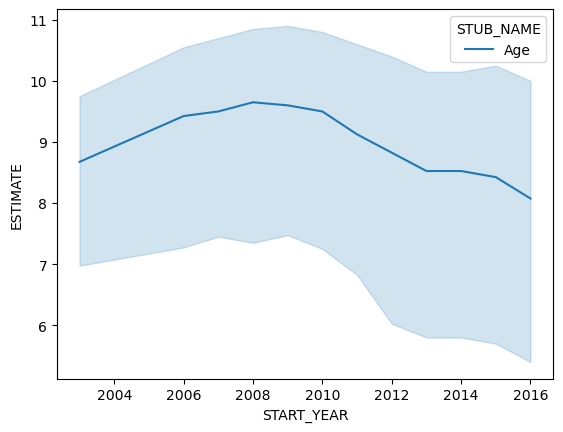

The line plot above shows how the prevalence of Asthma has varied across different age groups over the years.


In [8]:
asthma_age_df = df[(df['PANEL_SIMPLE'] == 'Current asthma') & (df['STUB_NAME'].str.contains('Age'))]
sns.lineplot(data=asthma_age_df, x='START_YEAR', y='ESTIMATE', hue='STUB_NAME')
plt.show()
print("The line plot above shows how the prevalence of Asthma has varied across different age groups over the years.")

### What is the average prevalence of each health condition for each gender?

In [9]:
# Filter the DataFrame to include only rows where STUB_NAME is 'Sex'
gender_avg_prevalence = df[df['STUB_NAME'] == 'Sex'].groupby(['PANEL_SIMPLE', 'STUB_NAME'])['ESTIMATE'].mean().reset_index()

print("The average prevalence of each health condition for the 'Sex' category is as follows:")
print(gender_avg_prevalence)


The average prevalence of each health condition for the 'Sex' category is as follows:
                                   PANEL_SIMPLE STUB_NAME   ESTIMATE
0                                          ADHD       Sex   9.275000
1               Asthma attack in last 12 months       Sex   5.139286
2                                Current asthma       Sex   8.875000
3                                Ear infections       Sex   5.478571
4                                  Food allergy       Sex   4.989286
5              Hay fever or respiratory allergy       Sex  16.375000
6  Serious emotional or behavioral difficulties       Sex   5.545833
7                                  Skin allergy       Sex  11.135714


### Which year had the highest overall prevalence for all health conditions combined?

In [10]:
highest_prevalence_year = df.groupby('START_YEAR')['ESTIMATE'].sum().idxmax()
print(f"The year with the highest overall prevalence for all health conditions combined is {highest_prevalence_year}.")

The year with the highest overall prevalence for all health conditions combined is 2010.


### Analysis
The analysis of the pediatric health conditions dataset has yielded some startling and noteworthy insights, which have profound implications for healthcare policies and interventions. One of the most startling revelations is that Skin Allergy has seen the most significant increase in prevalence over the years. This dramatic rise should trigger immediate attention from healthcare institutions and policy-makers. The underlying causes for this escalation, be it environmental factors or lifestyle changes, need to be urgently investigated.

Furthermore, the near-perfect correlation of 0.98 between the prevalence of ADHD and Food Allergies raises questions about potential common triggers or underlying genetic factors for these conditions. This finding is quite significant and warrants a more in-depth, possibly biogenetic, study to understand the intricacies of how these two conditions might be interrelated. Are children with ADHD more susceptible to food allergies, or does one condition exacerbate the other? These are questions that healthcare professionals must now consider.

The variation in the prevalence of Asthma across different age groups also offers a unique perspective. It implies that age-specific intervention strategies might be more effective than a one-size-fits-all approach. The healthcare system must adapt its preventive and treatment measures to cater to these age-specific needs for better asthma management.

Regarding gender-specific prevalence, the data indicates that conditions like ADHD, Asthma, and Skin Allergy are more prevalent under the "Sex" category, which unfortunately, doesn't distinguish between males and females. The lack of more granular data here hinders the opportunity for gender-specific interventions, which is a limitation of the dataset and the study.

# Vizualisation

### Trends in Various Health Conditions Among Children Under Age 18

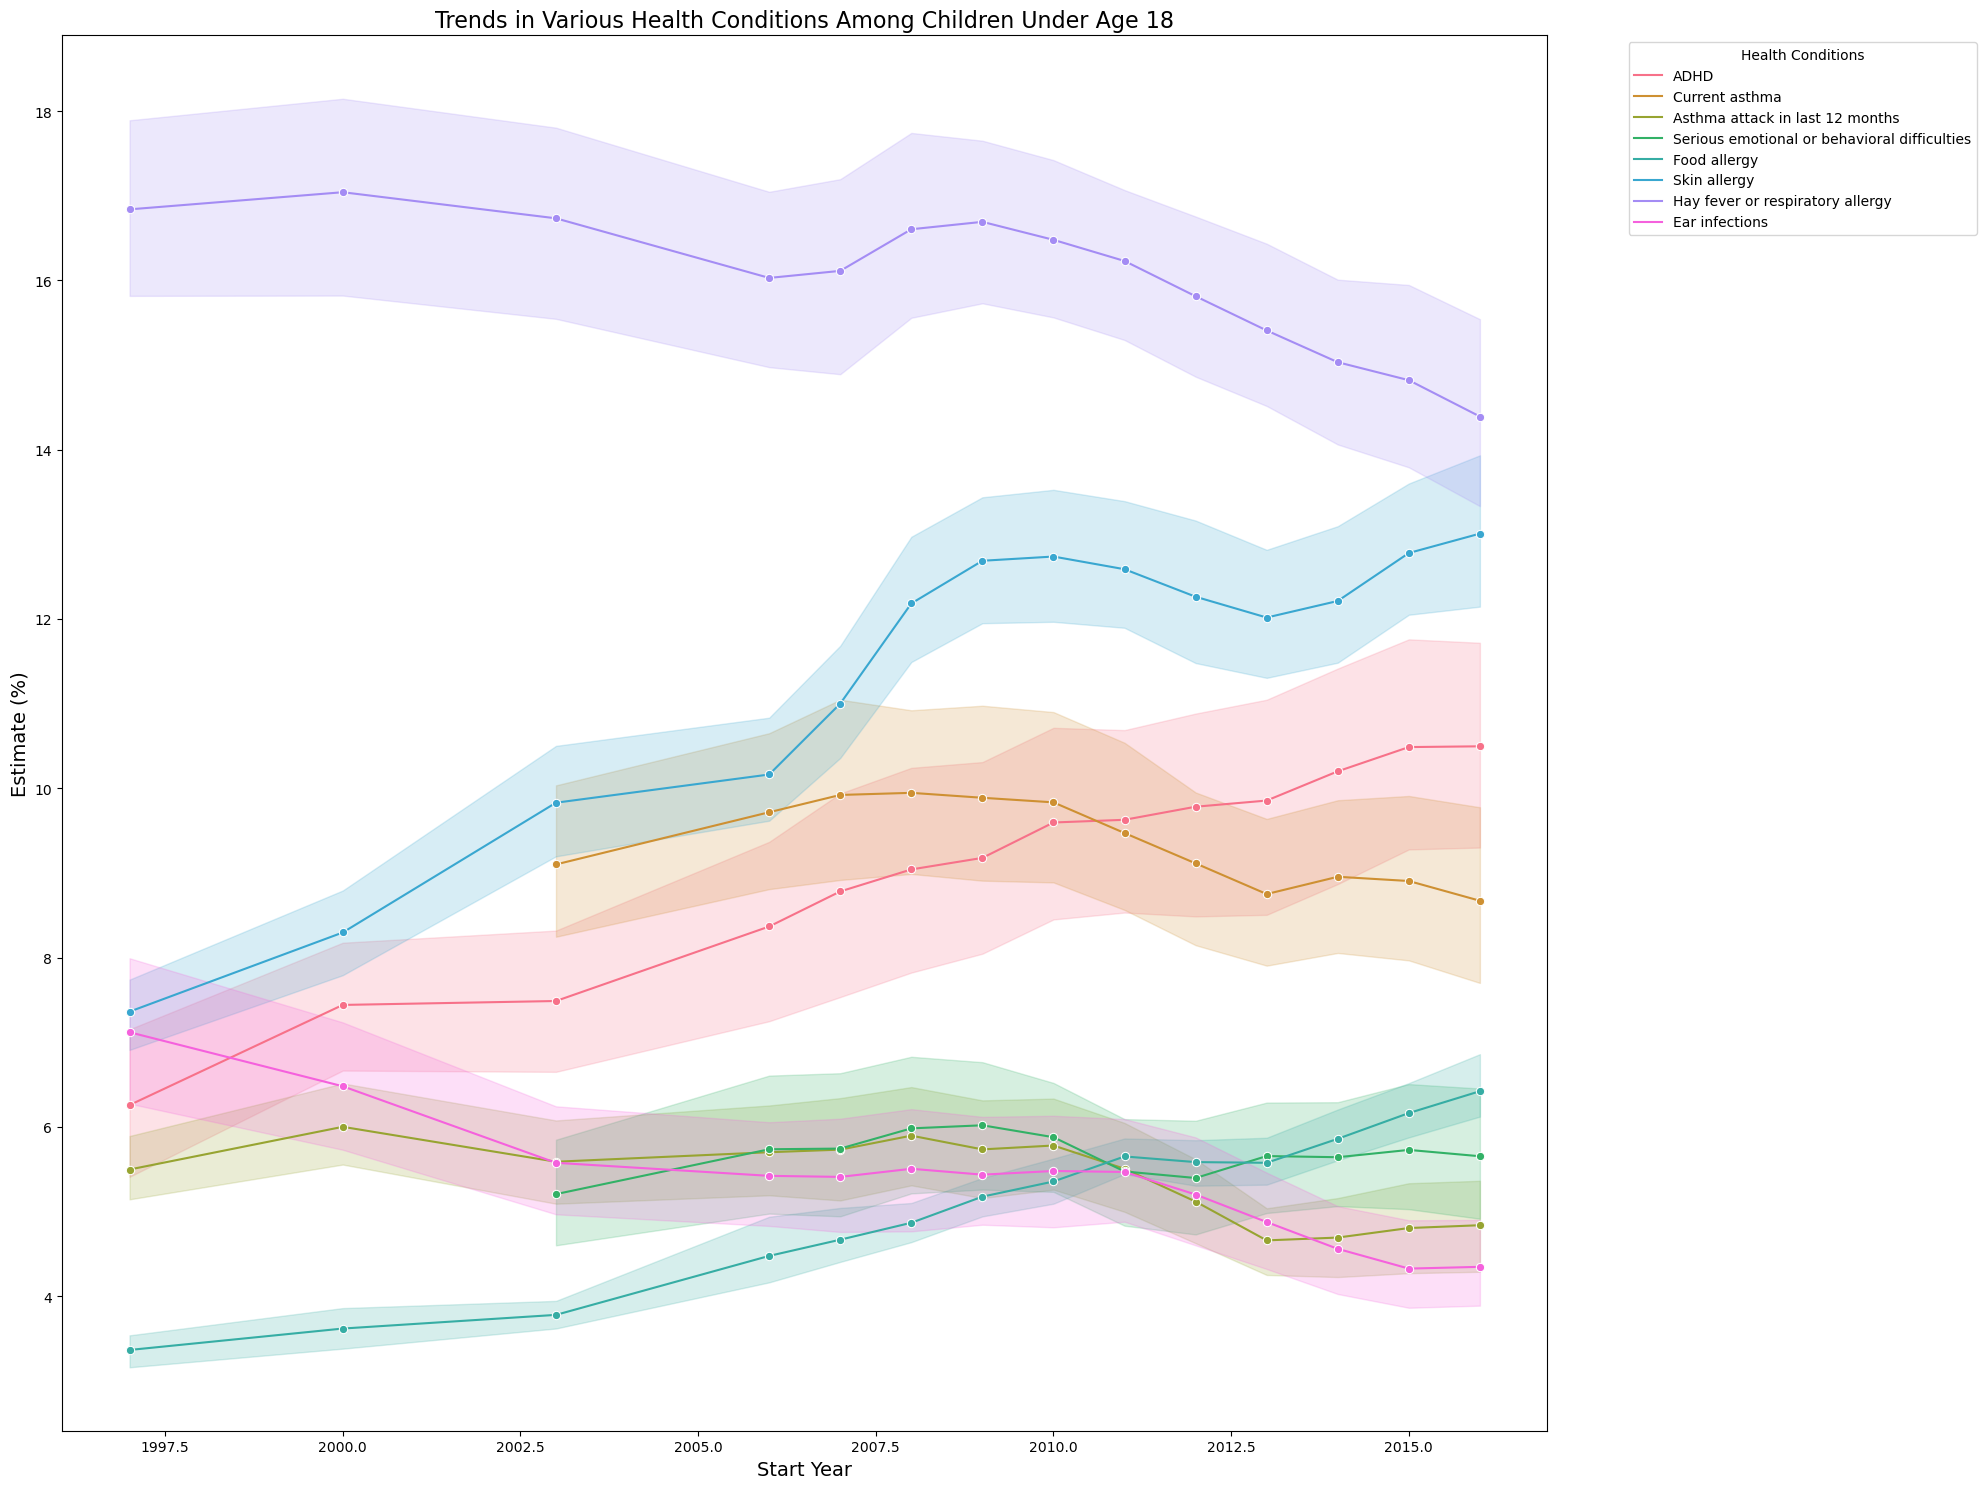

In [11]:
# Initialize the figure again
plt.figure(figsize=(20, 15))

# Create a new color palette with the corrected number of unique values
palette = sns.color_palette("husl", len(unique_panel_simple_all))

# Plotting trends for each health condition over the years
sns.lineplot(data=df, x='START_YEAR', y='ESTIMATE', hue='PANEL_SIMPLE', palette=palette, marker="o")

# Adding titles and labels
plt.title('Trends in Various Health Conditions Among Children Under Age 18', fontsize=16)
plt.xlabel('Start Year', fontsize=14)
plt.ylabel('Estimate (%)', fontsize=14)
plt.legend(title='Health Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


### Prevalence of Health Conditions by Age Groups Over Years

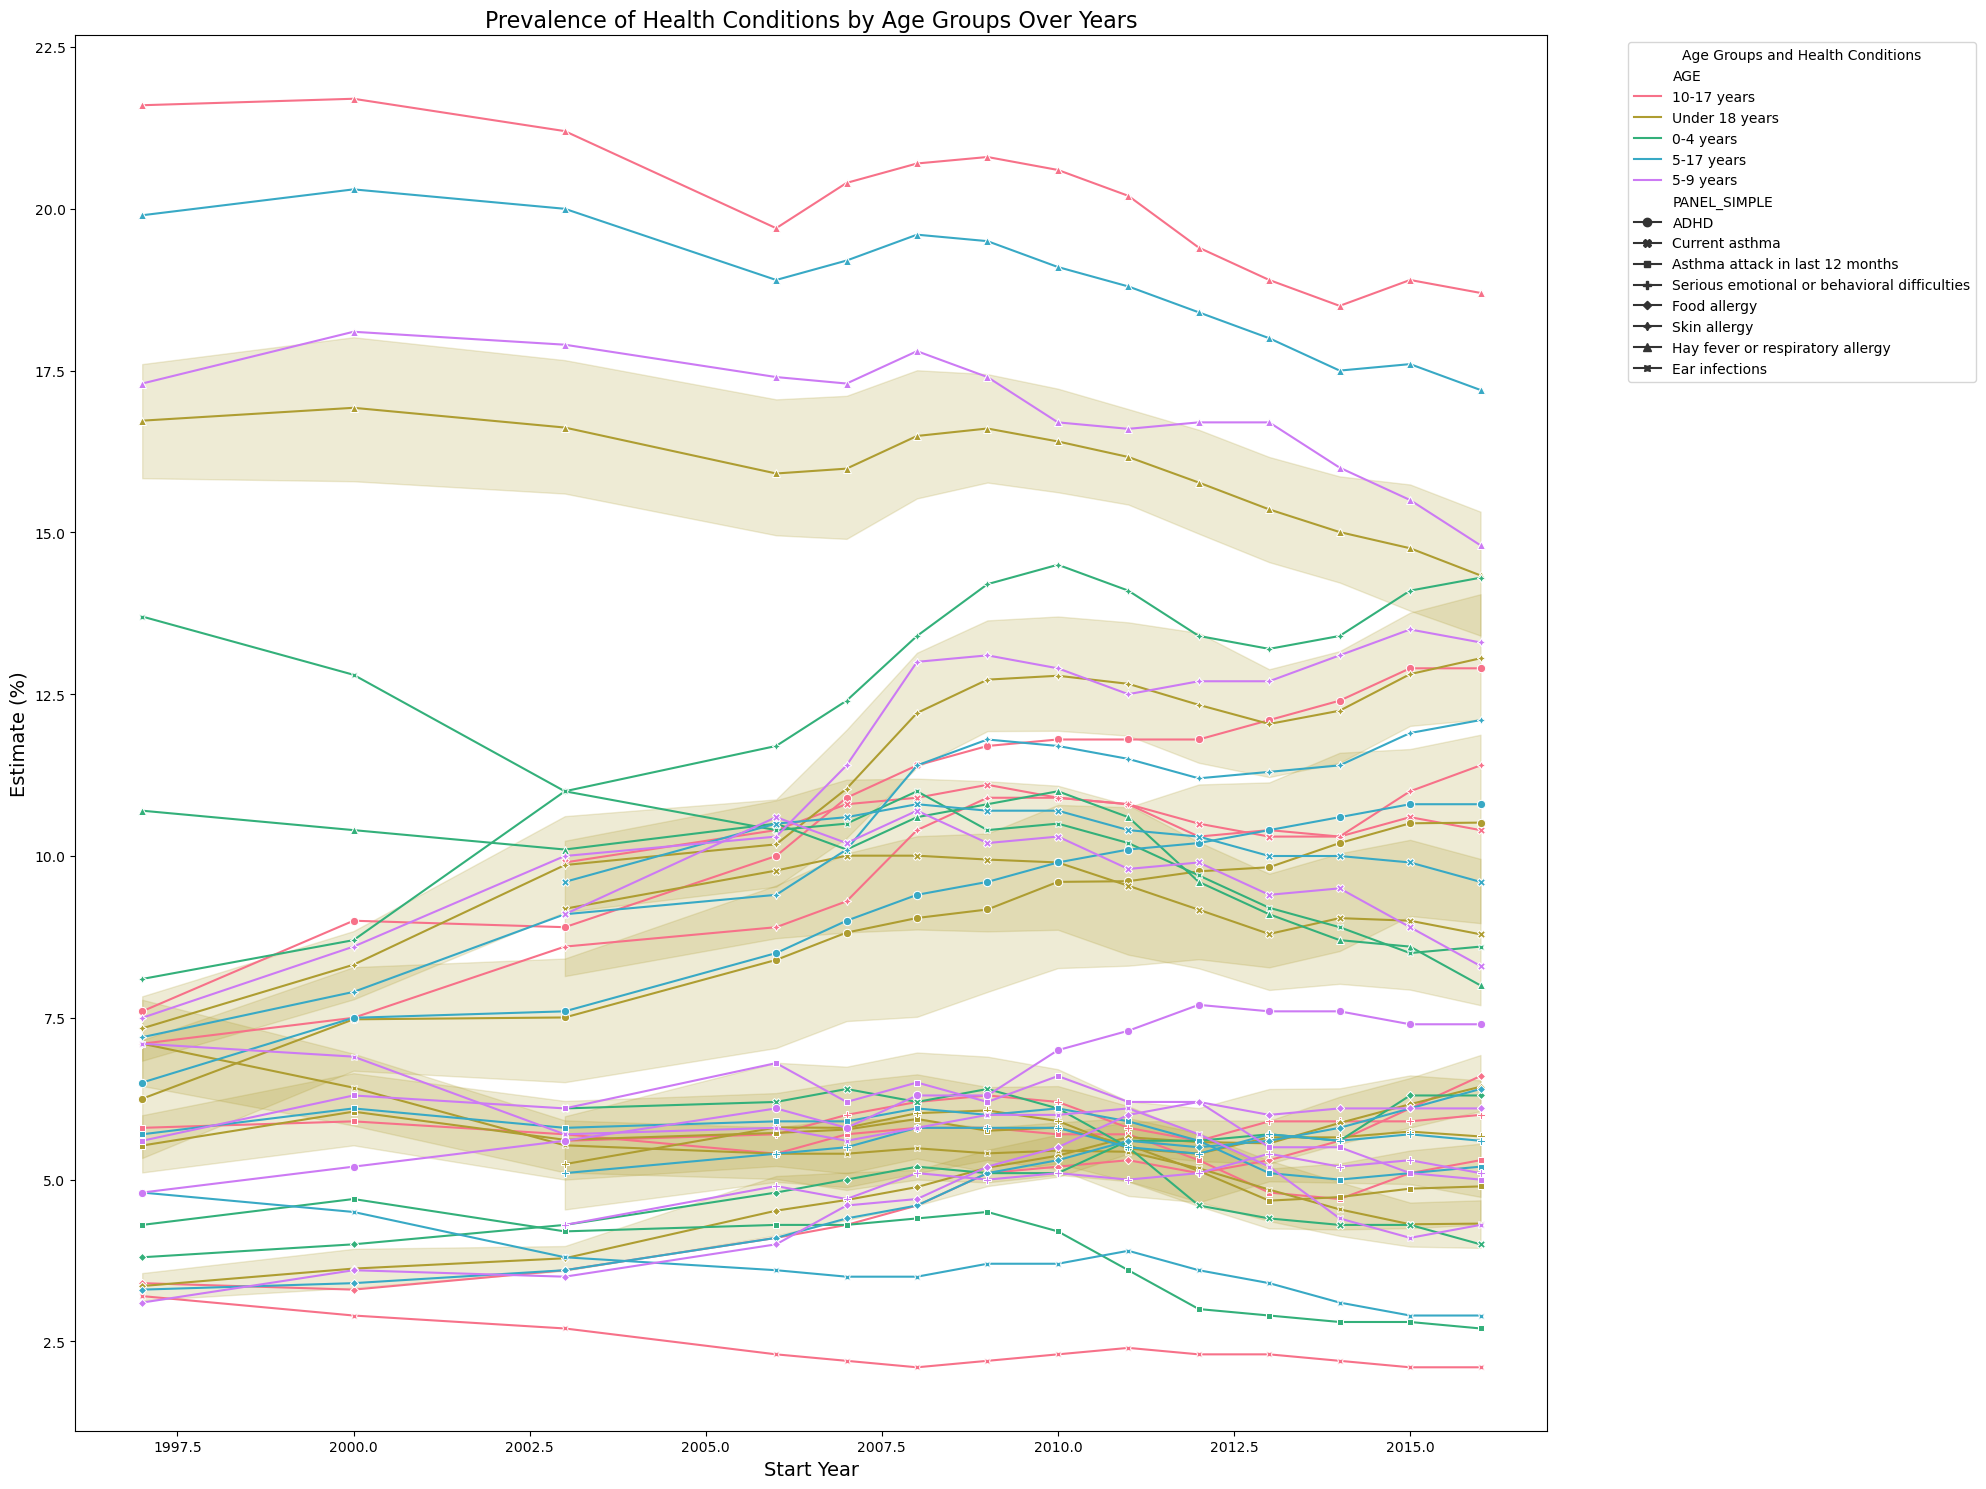

In [12]:
# Initialize the figure
plt.figure(figsize=(20, 15))

# Create a color palette
palette = sns.color_palette("husl", len(df['AGE'].unique()))

# Multi-Line Plot with Age Groups
sns.lineplot(data=df, x='START_YEAR', y='ESTIMATE', hue='AGE', style='PANEL_SIMPLE', markers=True, dashes=False, palette=palette)

# Adding titles and labels
plt.title('Prevalence of Health Conditions by Age Groups Over Years', fontsize=16)
plt.xlabel('Start Year', fontsize=14)
plt.ylabel('Estimate (%)', fontsize=14)
plt.legend(title='Age Groups and Health Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


### Heatmap of Average Prevalence of Health Conditions Over Years

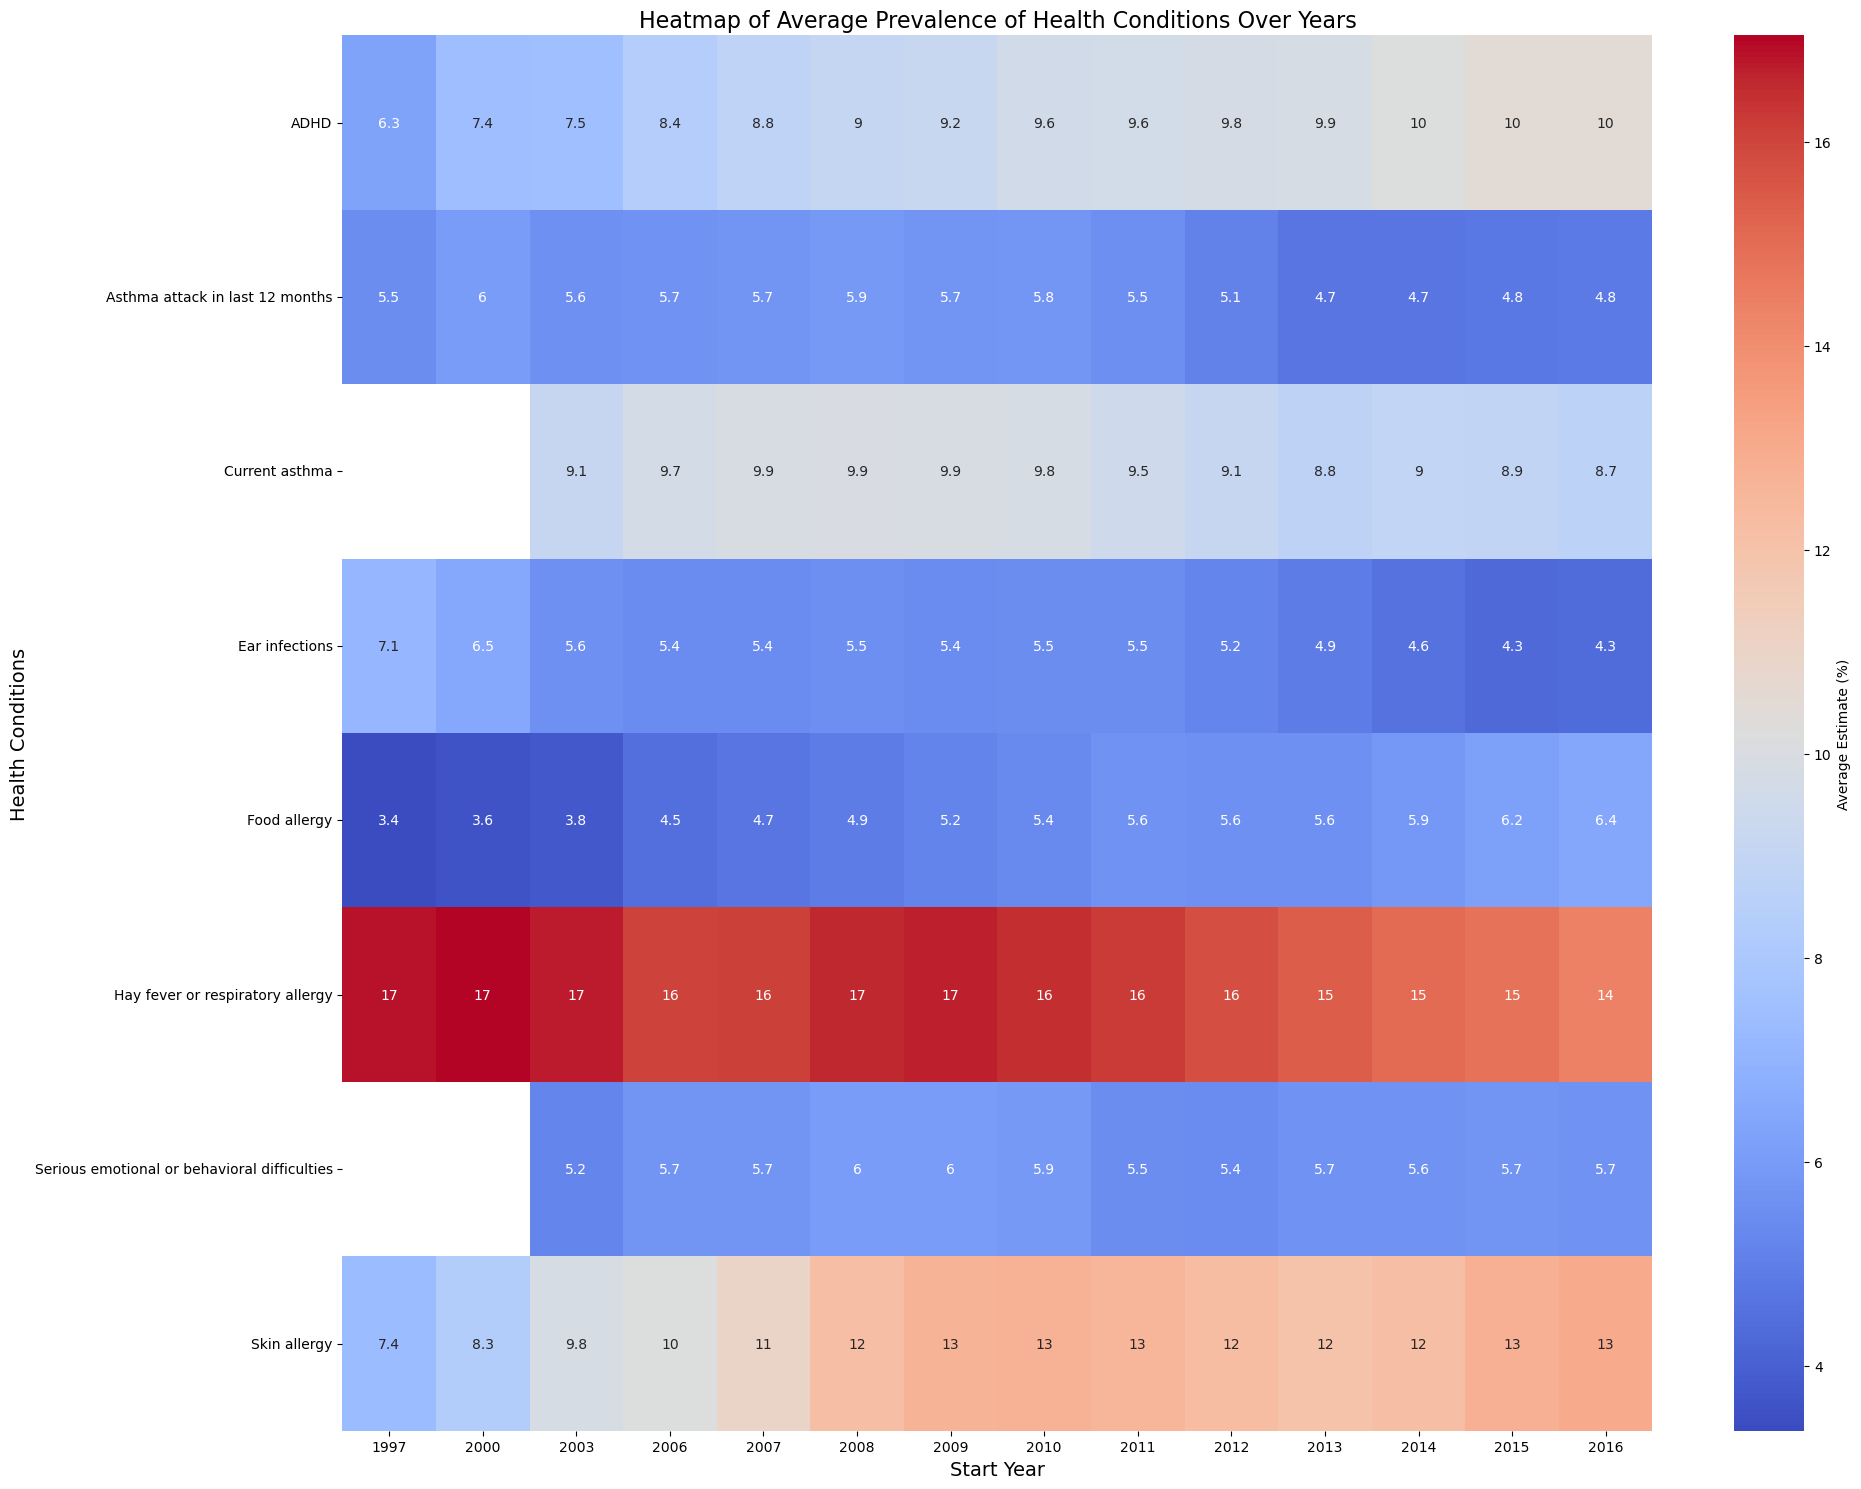

In [13]:
# Initialize the figure
plt.figure(figsize=(20, 15))

# Heatmap for Year and Condition
heatmap_data = df.pivot_table(values='ESTIMATE', index='PANEL_SIMPLE', columns='START_YEAR', aggfunc='mean')
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', cbar_kws={'label': 'Average Estimate (%)'})

# Adding titles and labels
plt.title('Heatmap of Average Prevalence of Health Conditions Over Years', fontsize=16)
plt.xlabel('Start Year', fontsize=14)
plt.ylabel('Health Conditions', fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()


### Area Chart of Average Prevalence by Units Over Years

<Figure size 5000x1000 with 0 Axes>

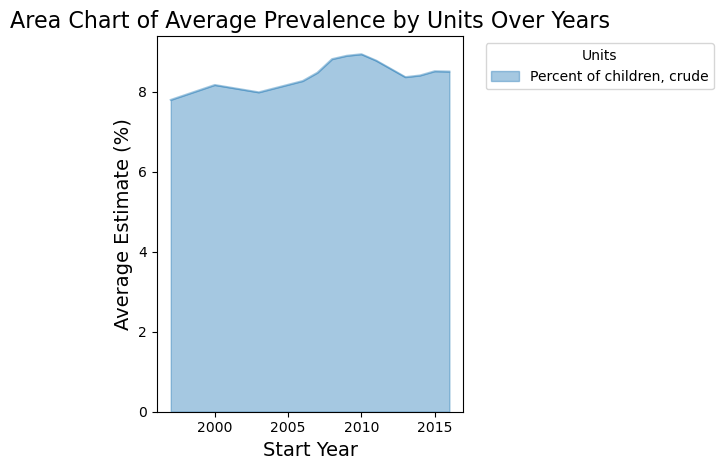

In [15]:
# Initialize the figure
plt.figure(figsize=(50, 10))

# Area Chart with Units
area_data = df.pivot_table(values='ESTIMATE', index='START_YEAR', columns='UNIT', aggfunc='mean')
area_data.plot.area(alpha=0.4)

# Adding titles and labels
plt.title('Area Chart of Average Prevalence by Units Over Years', fontsize=16)
plt.xlabel('Start Year', fontsize=14)
plt.ylabel('Average Estimate (%)', fontsize=14)
plt.legend(title='Units', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


### Prevalence of Health Conditions by Population Categories Over Years

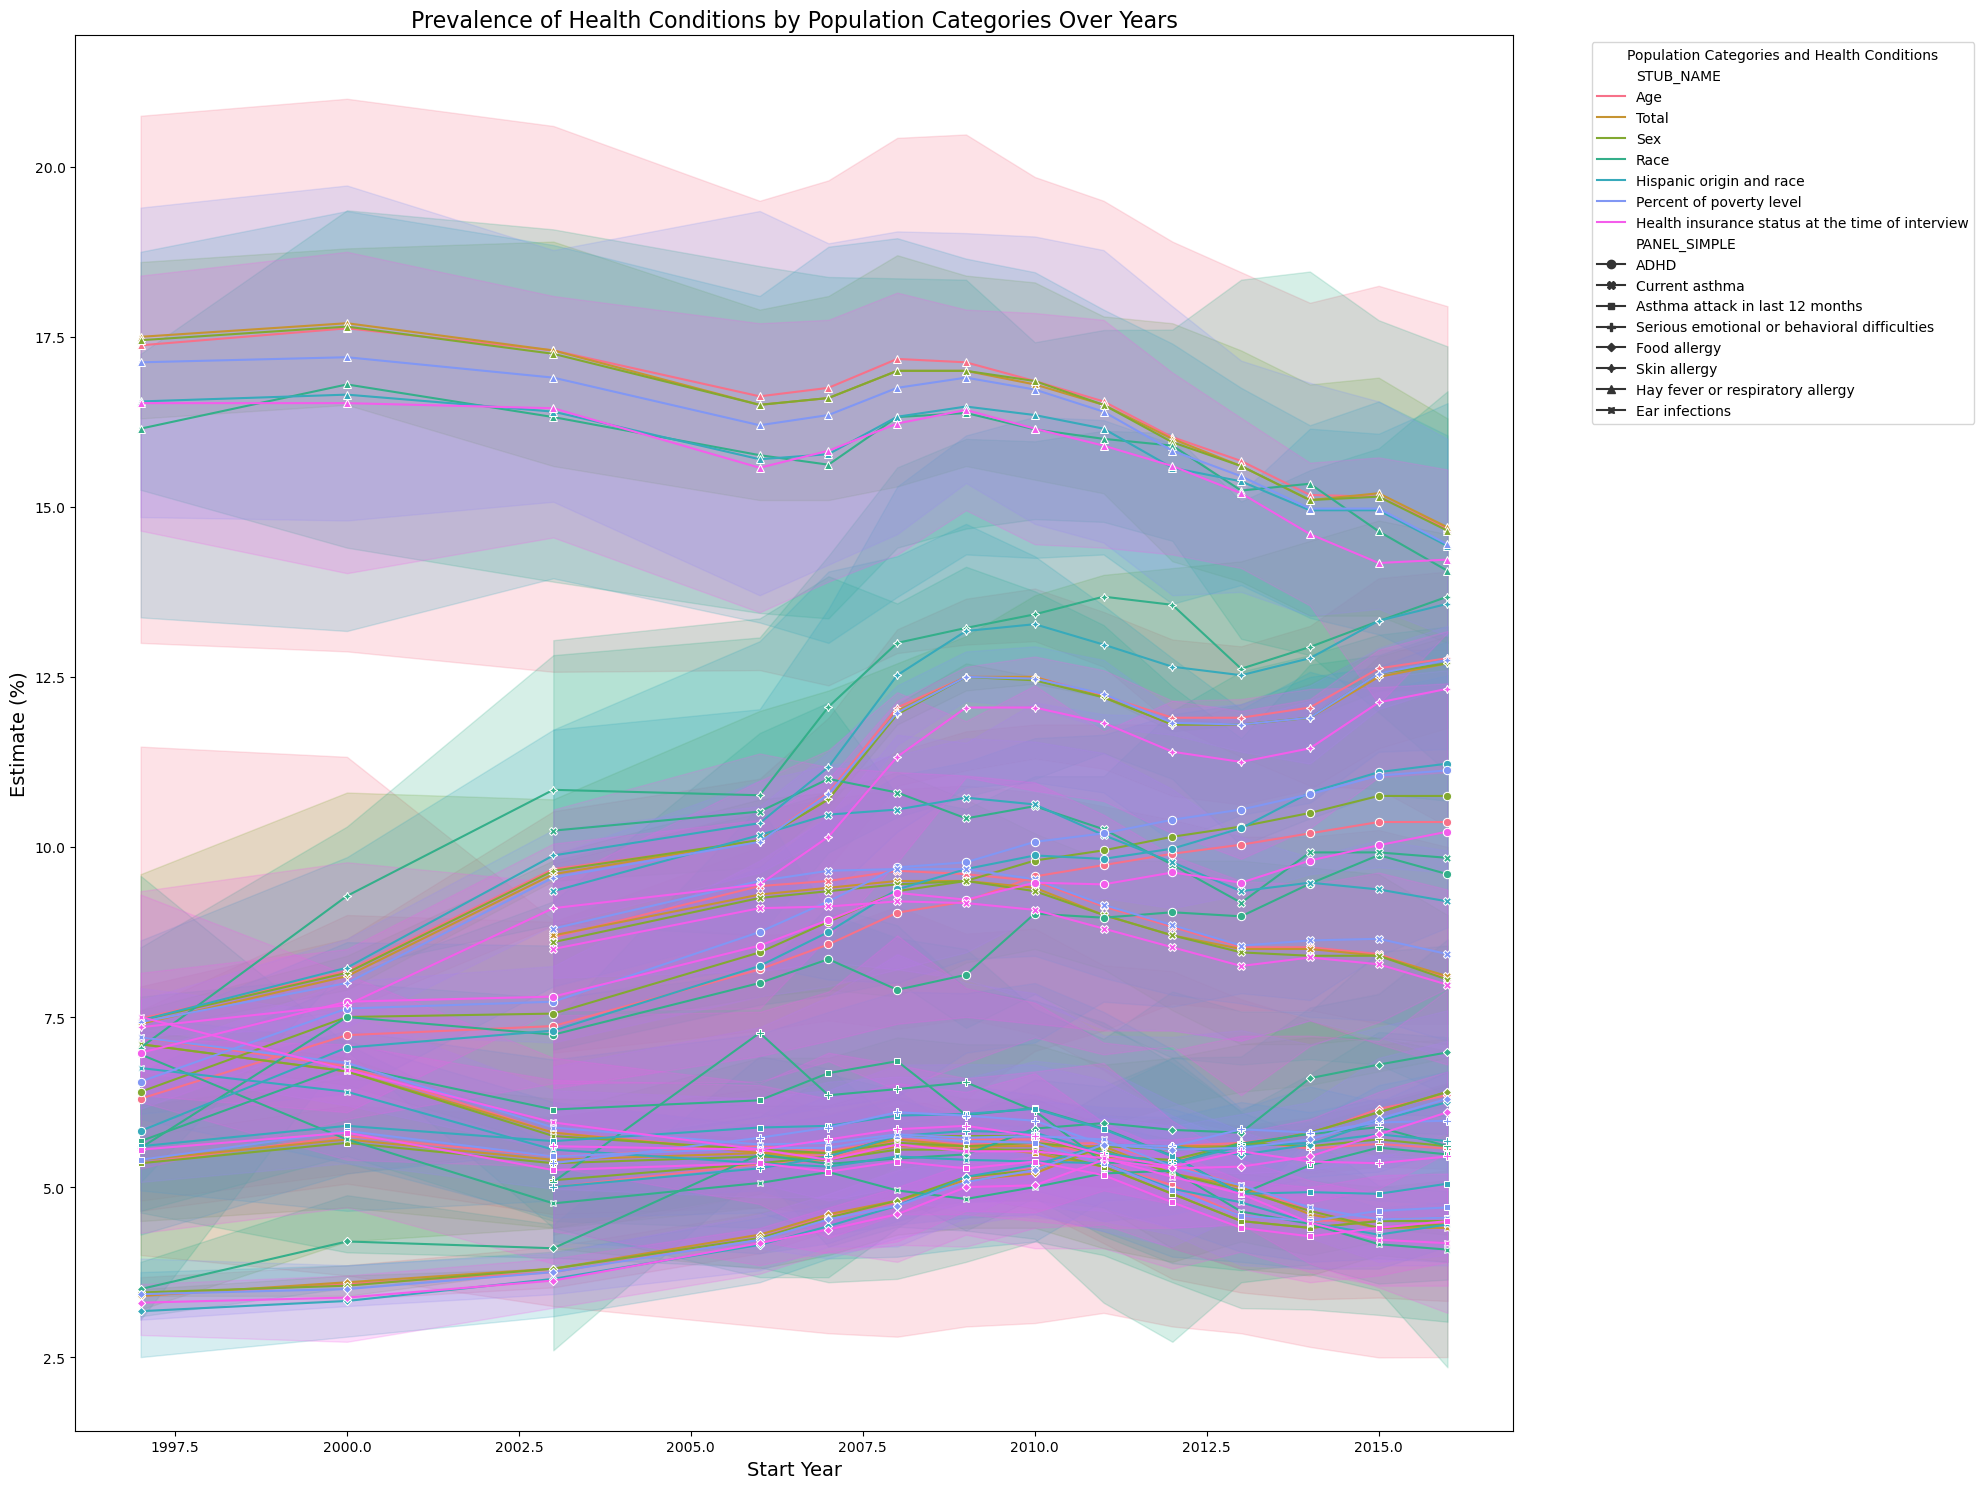

In [16]:
# Initialize the figure
plt.figure(figsize=(20, 15))

# Create a color palette
palette = sns.color_palette("husl", len(df['STUB_NAME'].unique()))

# Multi-Line Plot with Stub Names
sns.lineplot(data=df, x='START_YEAR', y='ESTIMATE', hue='STUB_NAME', style='PANEL_SIMPLE', markers=True, dashes=False, palette=palette)

# Adding titles and labels
plt.title('Prevalence of Health Conditions by Population Categories Over Years', fontsize=16)
plt.xlabel('Start Year', fontsize=14)
plt.ylabel('Estimate (%)', fontsize=14)
plt.legend(title='Population Categories and Health Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


### Box Plot of Yearly Distribution of Prevalence Estimates

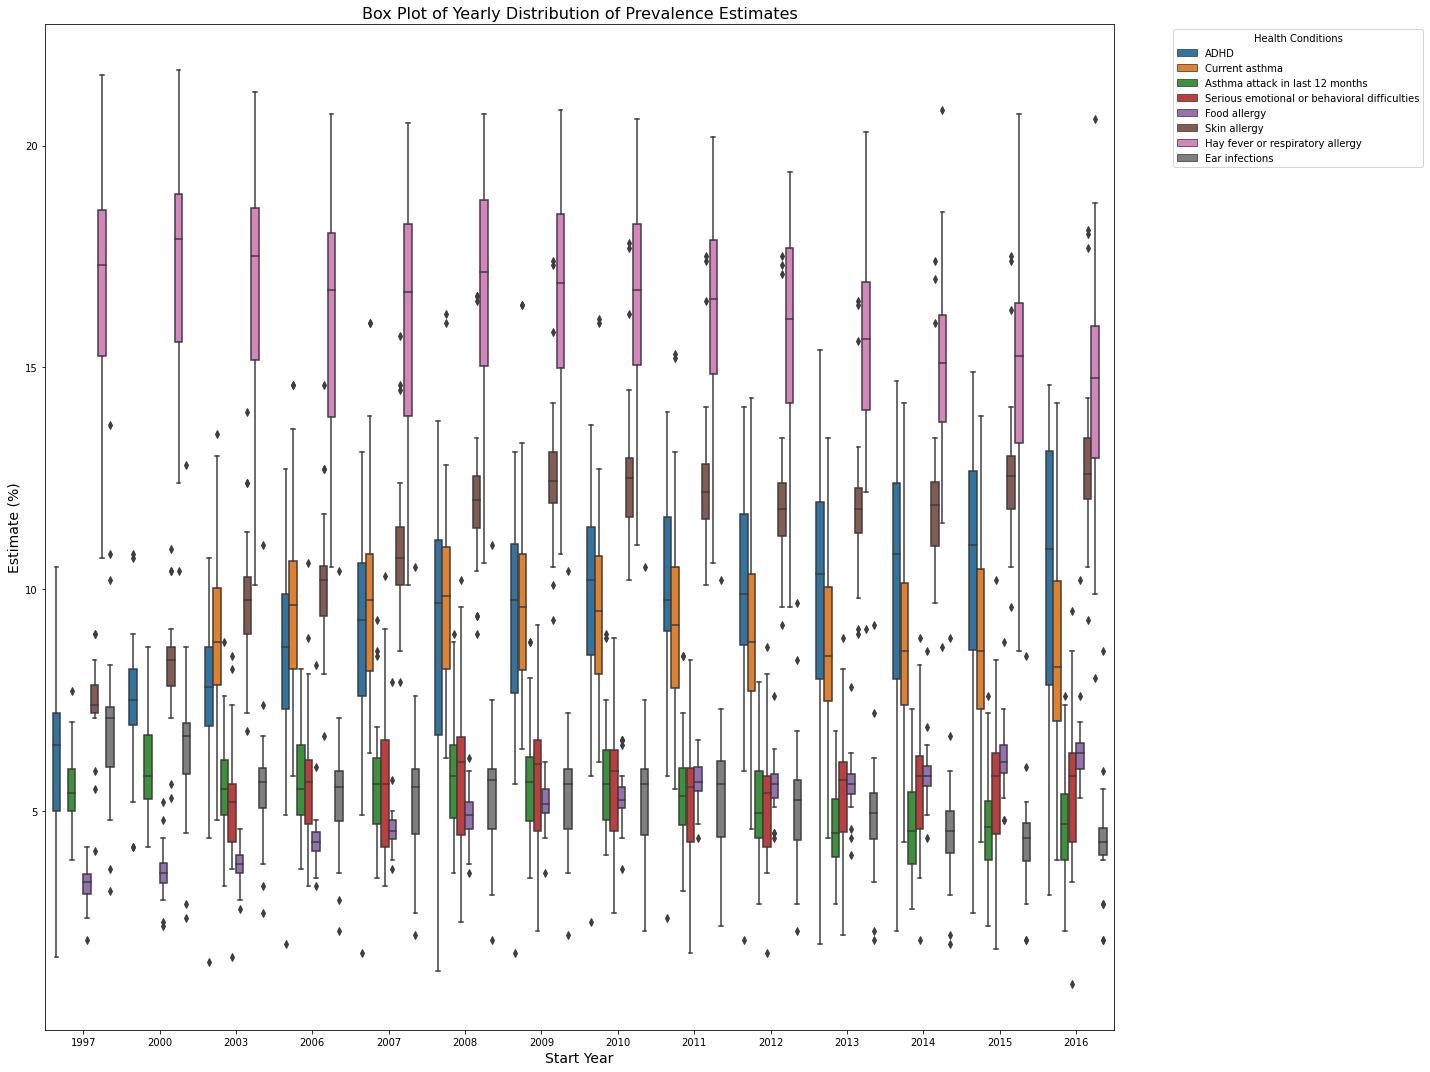

In [30]:
# Initialize the figure
plt.figure(figsize=(20, 15))

# Box Plot for Yearly Distribution
sns.boxplot(data=df, x='START_YEAR', y='ESTIMATE', hue='PANEL_SIMPLE')

# Adding titles and labels
plt.title('Box Plot of Yearly Distribution of Prevalence Estimates', fontsize=16)
plt.xlabel('Start Year', fontsize=14)
plt.ylabel('Estimate (%)', fontsize=14)
plt.legend(title='Health Conditions', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.tight_layout()
plt.show()


# Data Modelling and Evaluation

###  Linear Regression Modeling

In [17]:
# Initialize a dictionary to store model evaluation metrics
model_metrics = {}

# Loop through each unique health condition to fit a linear regression model
for condition in df['PANEL_SIMPLE'].unique():
    # Filter data for the current health condition
    condition_data = df[df['PANEL_SIMPLE'] == condition]
    
    # Prepare the feature matrix (X) and target vector (y)
    X = condition_data[['START_YEAR']]
    y = condition_data['ESTIMATE']
    
    # Initialize and fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Make predictions
    y_pred = model.predict(X)
    
    # Calculate R-squared value for the model
    r2 = r2_score(y, y_pred)
    
    # Store the model metrics
    model_metrics[condition] = {'Slope': model.coef_[0], 'Intercept': model.intercept_, 'R-squared': r2}

# Display the model metrics for each health condition
model_metrics


{'ADHD': {'Slope': 0.22188120751861423,
  'Intercept': -436.63940831227586,
  'R-squared': 0.16439101410089174},
 'Current asthma': {'Slope': -0.07839262187088274,
  'Intercept': 166.9508563899868,
  'R-squared': 0.013804904894114567},
 'Asthma attack in last 12 months': {'Slope': -0.05874322566325308,
  'Intercept': 123.38865900501264,
  'R-squared': 0.05543284939558657},
 'Serious emotional or behavioral difficulties': {'Slope': 0.005906641092846855,
  'Intercept': -6.19707282463419,
  'R-squared': 0.00016559524186576802},
 'Food allergy': {'Slope': 0.1672088001079767,
  'Intercept': -330.8244349964756,
  'R-squared': 0.6200384929308195},
 'Skin allergy': {'Slope': 0.29396388923476585,
  'Intercept': -579.1007725770106,
  'R-squared': 0.4044055648905055},
 'Hay fever or respiratory allergy': {'Slope': -0.12130609614074668,
  'Intercept': 259.6785708530789,
  'R-squared': 0.0593969738727117},
 'Ear infections': {'Slope': -0.126102389465358,
  'Intercept': 258.6631370080059,
  'R-squar

### Random Forest Modeling

In [18]:
# Initialize a dictionary to store Random Forest model evaluation metrics
rf_model_metrics = {}

# Loop through each unique health condition to fit a Random Forest model
for condition in df['PANEL_SIMPLE'].unique():
    # Filter data for the current health condition
    condition_data = df[df['PANEL_SIMPLE'] == condition]
    
    # Prepare the feature matrix (X) and target vector (y)
    X = condition_data[['START_YEAR']]
    y = condition_data['ESTIMATE']
    
    # Initialize and fit the Random Forest model
    rf_model = RandomForestRegressor(n_estimators=50, random_state=42)
    rf_model.fit(X, y)
    
    # Make predictions
    y_pred_rf = rf_model.predict(X)
    
    # Calculate R-squared value for the model
    r2_rf = r2_score(y, y_pred_rf)
    
    # Store the model metrics
    rf_model_metrics[condition] = {'R-squared': r2_rf}

# Display the Random Forest model metrics for comparison with Linear Regression
rf_model_metrics, model_metrics


({'ADHD': {'R-squared': 0.16671913537004657},
  'Current asthma': {'R-squared': 0.03457327214343875},
  'Asthma attack in last 12 months': {'R-squared': 0.11325640575520945},
  'Serious emotional or behavioral difficulties': {'R-squared': 0.01568106890188803},
  'Food allergy': {'R-squared': 0.6377535017084718},
  'Skin allergy': {'R-squared': 0.4716399919001478},
  'Hay fever or respiratory allergy': {'R-squared': 0.08544147566790905},
  'Ear infections': {'R-squared': 0.17134374401186947}},
 {'ADHD': {'Slope': 0.22188120751861423,
   'Intercept': -436.63940831227586,
   'R-squared': 0.16439101410089174},
  'Current asthma': {'Slope': -0.07839262187088274,
   'Intercept': 166.9508563899868,
   'R-squared': 0.013804904894114567},
  'Asthma attack in last 12 months': {'Slope': -0.05874322566325308,
   'Intercept': 123.38865900501264,
   'R-squared': 0.05543284939558657},
  'Serious emotional or behavioral difficulties': {'Slope': 0.005906641092846855,
   'Intercept': -6.19707282463419,
